In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('StudentPerformanceFactors.csv')

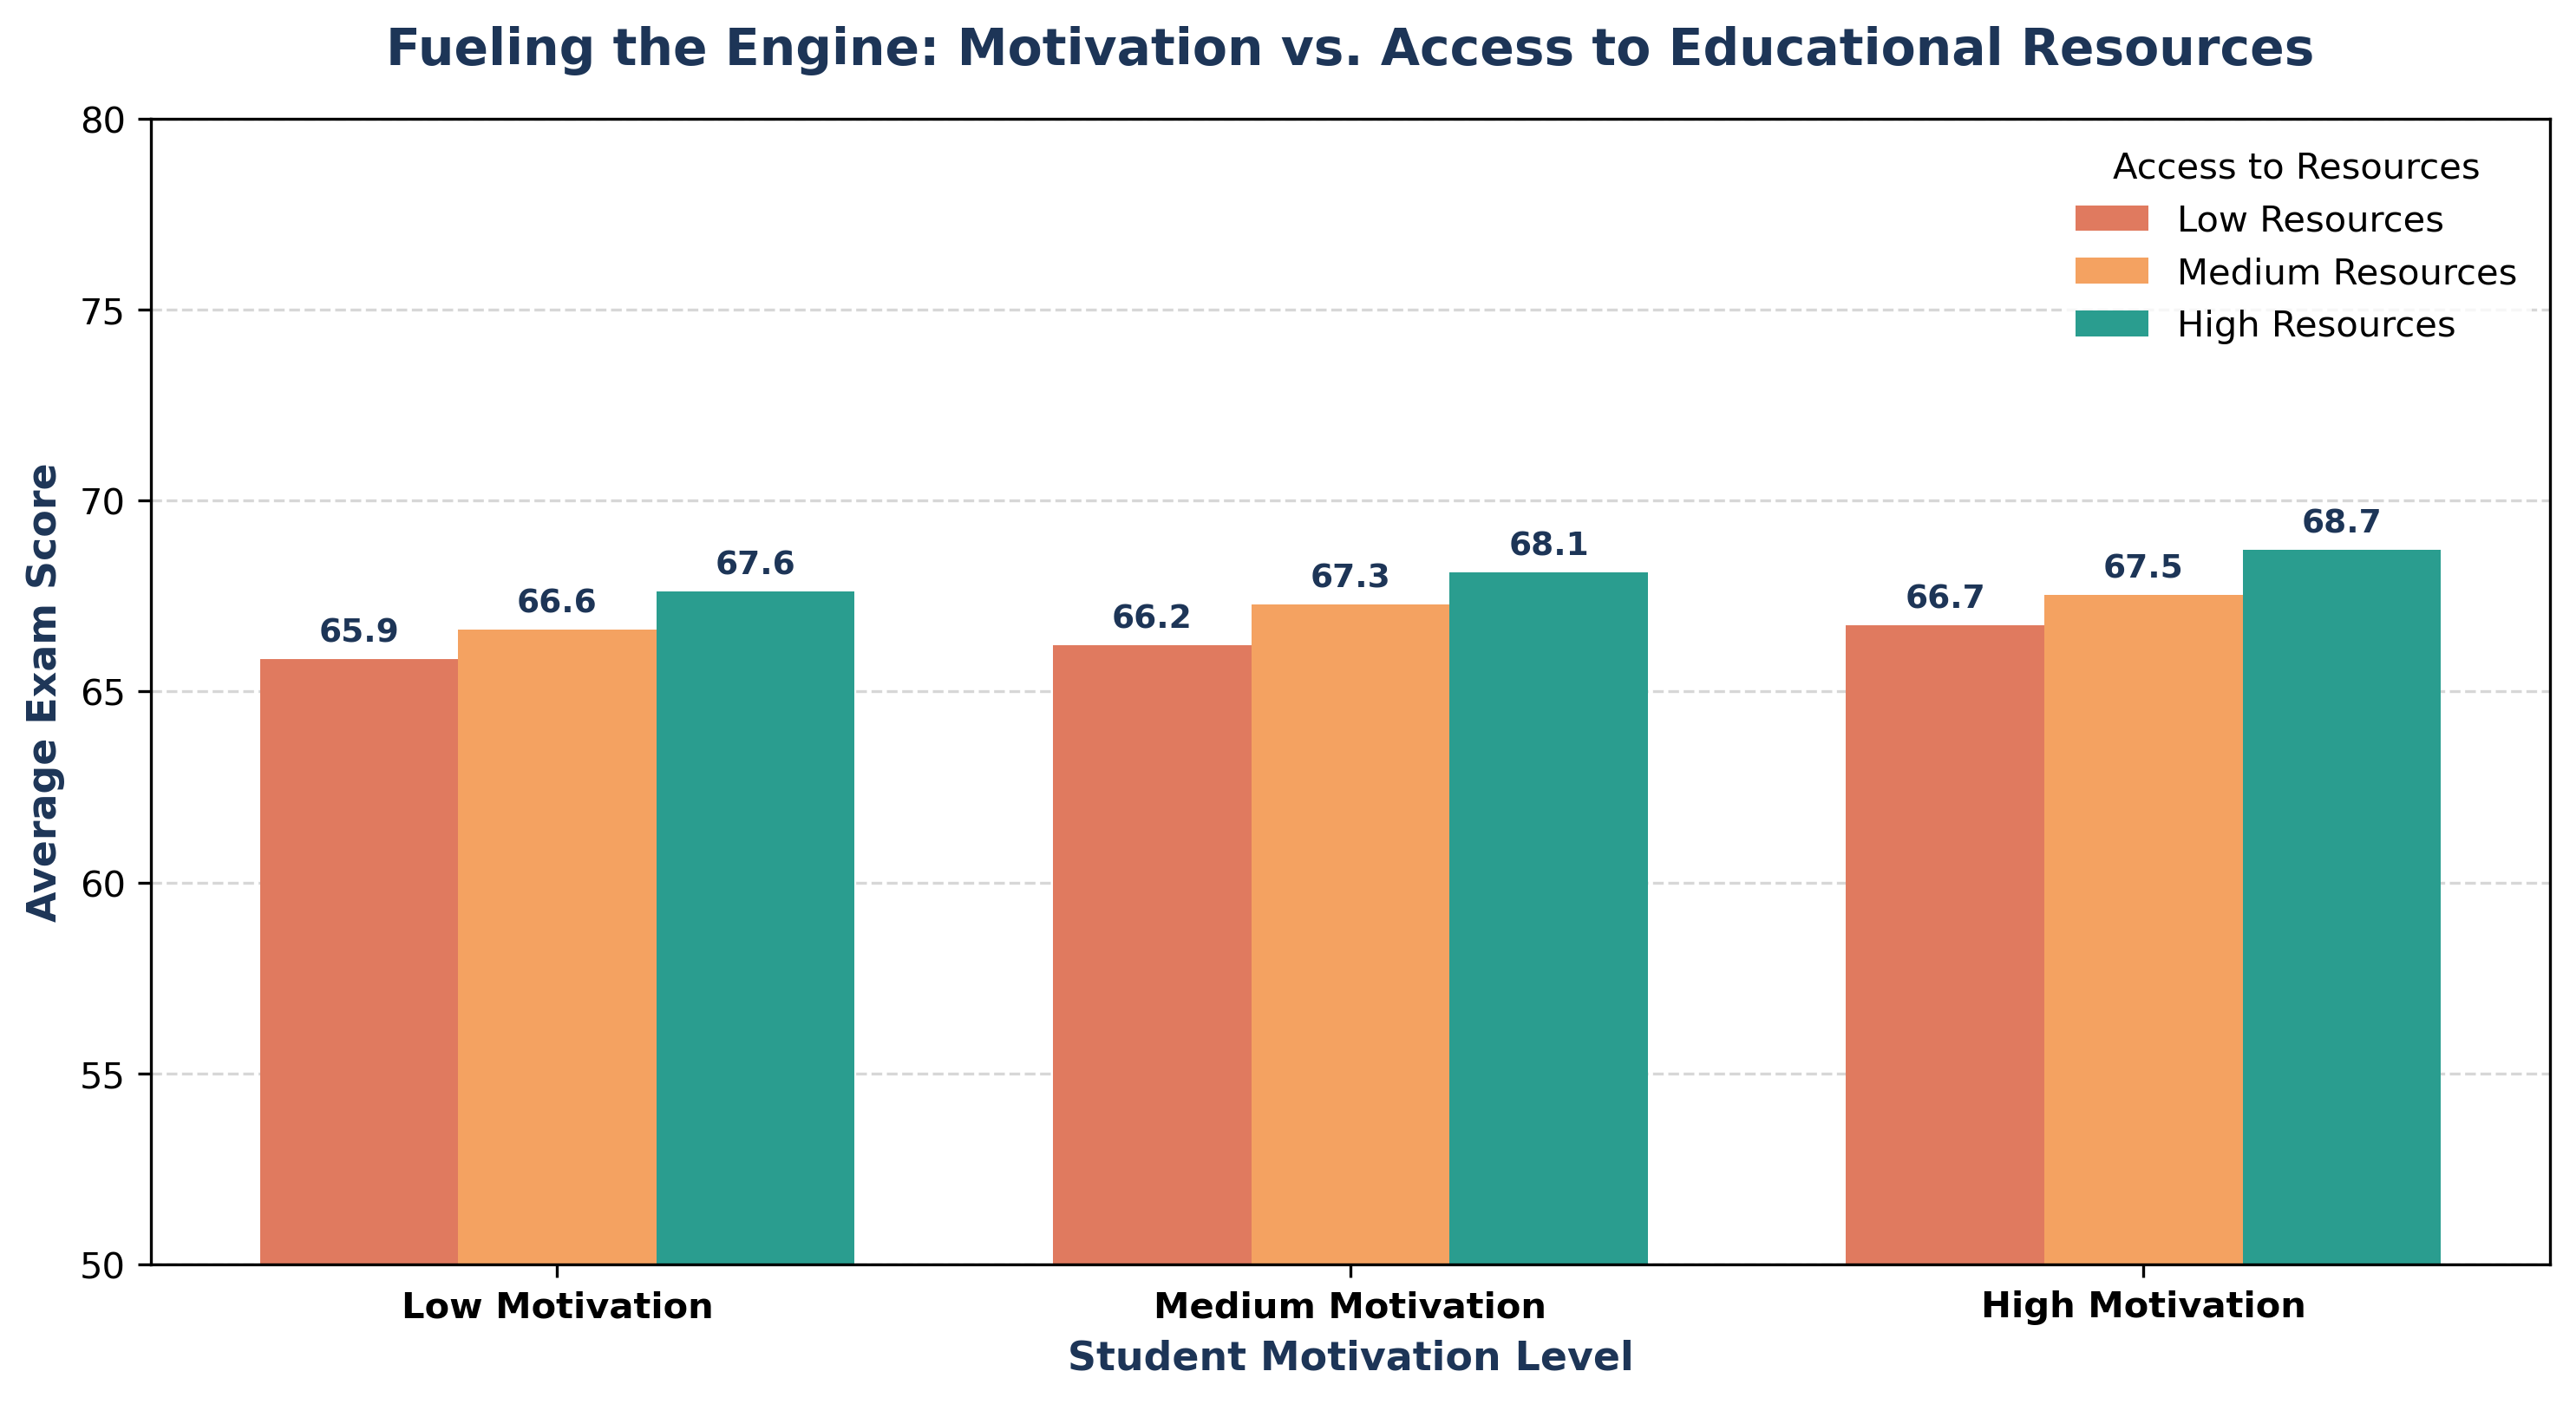

In [11]:
grouped = df.groupby(['Motivation_Level', 'Access_to_Resources'])['Exam_Score'].mean().unstack()
grouped = grouped.loc[['Low', 'Medium', 'High'], ['Low', 'Medium', 'High']]

x = np.arange(len(grouped.index))
width = 0.25

colors = ['#E07A5F', '#F4A261', '#2A9D8F']

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

rects1 = ax.bar(x - width, grouped['Low'], width, label='Low Resources', color=colors[0])
rects2 = ax.bar(x, grouped['Medium'], width, label='Medium Resources', color=colors[1])
rects3 = ax.bar(x + width, grouped['High'], width, label='High Resources', color=colors[2])

ax.set_title("Fueling the Engine: Motivation vs. Access to Educational Resources", fontsize=14, fontweight='bold', pad=15, color='#1D3557')
ax.set_xlabel("Student Motivation Level", fontsize=11, fontweight='bold', color='#1D3557')
ax.set_ylabel("Average Exam Score", fontsize=11, fontweight='bold', color='#1D3557')
ax.set_xticks(x)
ax.set_xticklabels(['Low Motivation', 'Medium Motivation', 'High Motivation'], fontsize=10, fontweight='bold')
ax.set_ylim(50, 80)
ax.legend(title="Access to Resources", frameon=True, facecolor='white', edgecolor='none')

for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1D3557')

ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()